In [3]:
#importing required libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


import optuna
import random
import joblib

In [2]:
#loading datasets
CSV_PATH = r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\dataset\train.csv"
train_df = pd.read_csv(CSV_PATH)
print(train_df.shape)

CSV_PATH = r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\dataset\test.csv"
test_df = pd.read_csv(CSV_PATH)
print(test_df.shape)

CSV_PATH = r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\dataset\validation.csv"
val_df = pd.read_csv(CSV_PATH)
print(val_df.shape)

(2407, 64)
(369, 64)
(31, 64)


In [3]:
#seperating X and y 
X_train = train_df.drop("gesture",axis=1)
y_train = train_df["gesture"]

X_test = test_df.drop("gesture",axis=1)
y_test = test_df["gesture"]

X_val = val_df.drop("gesture",axis=1)
y_val = val_df["gesture"]

In [4]:
#shapes of datasets
print("--train data--")
print(X_train.shape)
print(y_train.shape)

print("--test data--")
print(X_test.shape)
print(y_test.shape)

print("--validation data--")
print(X_val.shape)
print(y_val.shape)

--train data--
(2407, 63)
(2407,)
--test data--
(369, 63)
(369,)
--validation data--
(31, 63)
(31,)


In [5]:
#encoding target variable
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)
y_val = encoder.transform(y_val)
encoder.classes_

array(['paper', 'rock', 'scissors'], dtype=object)

In [6]:
# saving encoder for deployment

import os
os.makedirs(
    r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\model",
    exist_ok=True
)

joblib.dump(
    encoder,
    r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\model\label_encoder.pkl"
)

['C:\\Users\\hp\\Documents\\innomatics\\DL\\Rock_Paper_Scissor\\model\\label_encoder.pkl']

In [7]:
#normalize the landmarks
def normalize_landmarks(data):

    # Convert DataFrame to NumPy array
    data = np.array(data, dtype=np.float32)

    # Reshape from (samples, 63) -> (samples, 21, 3)
    data = data.reshape(-1, 21, 3)

    # Wrist landmark (landmark 0)
    wrist = data[:, 0, :]

    # Shift all landmarks so wrist becomes (0,0,0)
    data = data - wrist[:, None, :]

    # Flatten back to (samples, 63)
    data = data.reshape(-1, 63)

    return data

In [8]:
# Normalize landmarks
X_train = normalize_landmarks(X_train)
X_val = normalize_landmarks(X_val)
X_test = normalize_landmarks(X_test)

In [9]:
# scaling features
scaler = StandardScaler()
X_train = scaler.fit_transform(
    X_train
)
X_test = scaler.transform(
    X_test
)
X_val = scaler.transform(
    X_val
)

In [10]:
joblib.dump(
    scaler,
    r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\model\scaler.pkl"
)

['C:\\Users\\hp\\Documents\\innomatics\\DL\\Rock_Paper_Scissor\\model\\scaler.pkl']

In [11]:
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(2407, 63)
(369, 63)
(31, 63)


In [12]:
# baseline ann model

model = Sequential([

    Dense(
        63,
        activation="relu",
        input_shape=(63,)
    ),

    Dropout(0.3),


    Dense(
        64,
        activation="relu"
    ),

    Dropout(0.2),


    Dense(
        32,
        activation="relu"
    ),


    Dense(
        3,
        activation="softmax"
    )

])

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 63)                  │           4,032 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           4,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,307 (40.26 KB)

 Trainable params: 10,307 (40.26 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#compiling model
model.compile(

    optimizer="adam",

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [15]:
#checking imbalance
from collections import Counter
print(Counter(y_train))

Counter({np.int64(2): 840, np.int64(0): 834, np.int64(1): 733})


In [16]:
#reduces overfitting, reduces training time if no improvement is observed
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [17]:
#Training model
history = model.fit(

    X_train,
    y_train,
    validation_split = 0.2,
    epochs=50,
    callbacks=[early_stop]

)

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8234 - loss: 0.4632 - val_accuracy: 0.8527 - val_loss: 0.4225
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9917 - loss: 0.0460 - val_accuracy: 0.8444 - val_loss: 0.3900
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9958 - loss: 0.0206 - val_accuracy: 0.8651 - val_loss: 0.3462
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0079 - val_accuracy: 0.8755 - val_loss: 0.3456
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 0.9004 - val_loss: 0.3171
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0040 - val_accuracy: 0.8942 - val_loss: 0.3541
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9087 - val_loss: 0.3278
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0070 - val_accuracy: 0.8983 - val_loss

In [18]:
#Testing model
test_loss, test_accuracy = model.evaluate(X_test,y_test)
print(
    "Test Accuracy:",
    test_accuracy
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7290 - loss: 1.7759 
Test Accuracy: 0.7289972901344299


In [19]:
pred = np.argmax(
    model.predict(X_test),
    axis=1
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [20]:
print(
    classification_report(
        y_test,
        pred,
        target_names=encoder.classes_
    )
)

              precision    recall  f1-score   support

       paper       1.00      0.19      0.32       124
        rock       0.57      1.00      0.73       121
    scissors       0.93      1.00      0.96       124

    accuracy                           0.73       369
   macro avg       0.83      0.73      0.67       369
weighted avg       0.84      0.73      0.67       369



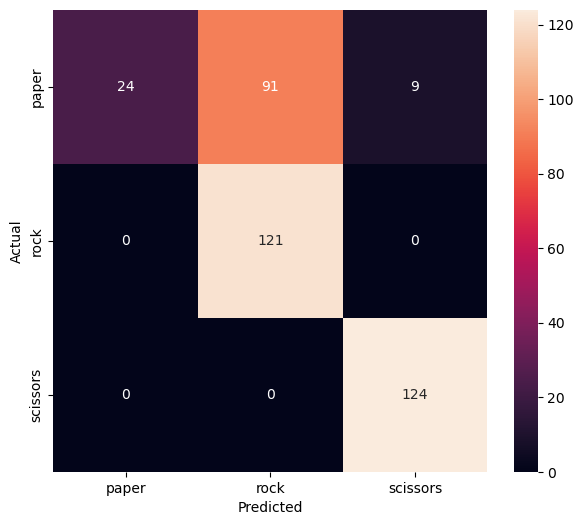

In [21]:
plt.figure(figsize=(7,6))


sns.heatmap(

    confusion_matrix(
        y_test,
        pred
    ),

    annot=True,

    fmt="d",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [22]:
BASELINE_PATH = r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\model\baseline_model.keras"
model.save(
    BASELINE_PATH
)

In [23]:
def create_model(trial):

    model = Sequential()

    # Number of hidden layers
    n_layers = trial.suggest_int(
        "n_layers",
        1,
        3
    )

    # Common dropout rate
    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.1,
        0.5
    )

    # Input layer
    model.add(
        Input(shape=(63,))
    )

    # Hidden layers
    for i in range(n_layers):

        units = trial.suggest_int(
            f"units_layer_{i}",
            32,
            128,
            step=32
        )

        model.add(
            Dense(
                units,
                activation="relu"
            )
        )

        model.add(
            Dropout(dropout_rate)
        )

    # Output layer
    model.add(
        Dense(
            3,
            activation="softmax"
        )
    )

    # Learning rate
    learning_rate = trial.suggest_float(
        "learning_rate",
        1e-5,
        1e-2,
        log=True
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=learning_rate
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [24]:

def objective(trial):

    model = create_model(trial)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    history = model.fit(

        X_train,
        y_train,

        validation_split=0.2,

        epochs=50,

        batch_size=trial.suggest_categorical(
            "batch_size",
            [16, 32, 64]
        ),

        callbacks=[early_stop],

        verbose=0

    )

    # Return the best validation accuracy
    return max(history.history["val_accuracy"])

In [25]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

[I 2026-08-05 12:01:59,904] A new study created in memory with name: no-name-3b8be290-405e-4e08-9bdd-096bb8a57d93
[I 2026-08-05 12:02:07,996] Trial 0 finished with value: 0.9730290174484253 and parameters: {'n_layers': 2, 'dropout_rate': 0.2805441838083982, 'units_layer_0': 128, 'units_layer_1': 96, 'learning_rate': 0.0008224016009271745, 'batch_size': 32}. Best is trial 0 with value: 0.9730290174484253.
[I 2026-08-05 12:02:13,461] Trial 1 finished with value: 0.9419087171554565 and parameters: {'n_layers': 1, 'dropout_rate': 0.25050233125116744, 'units_layer_0': 128, 'learning_rate': 0.003083085688591833, 'batch_size': 32}. Best is trial 0 with value: 0.9730290174484253.
[I 2026-08-05 12:02:16,614] Trial 2 finished with value: 0.9211618304252625 and parameters: {'n_layers': 2, 'dropout_rate': 0.4192688194686458, 'units_layer_0': 96, 'units_layer_1': 64, 'learning_rate': 0.0030365381573437414, 'batch_size': 64}. Best is trial 0 with value: 0.9730290174484253.
[I 2026-08-05 12:02:42,565

In [26]:
study.best_params

{'n_layers': 2,
 'dropout_rate': 0.2805441838083982,
 'units_layer_0': 128,
 'units_layer_1': 96,
 'learning_rate': 0.0008224016009271745,
 'batch_size': 32}

In [27]:
study.best_value

0.9730290174484253

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Model Building
final_model = Sequential([
    Dense(
        128,
        activation="relu",
        input_shape=(63,)
    ),

    Dropout(0.2805441838083982),

    Dense(
        96,
        activation="relu"
    ),

    Dense(
        3,
        activation="softmax"
    )
])

# Compile
final_model.compile(
    optimizer=Adam(learning_rate=0.0008224016009271745),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Training
history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/50


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9216 - loss: 0.2597 - val_accuracy: 0.8651 - val_loss: 0.4393
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9979 - loss: 0.0169 - val_accuracy: 0.8983 - val_loss: 0.3199
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9995 - loss: 0.0065 - val_accuracy: 0.9149 - val_loss: 0.2896
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 0.9232 - val_loss: 0.2690
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0019 - val_accuracy: 0.9253 - val_loss: 0.2355
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9253 - val_loss: 0.2515
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9253 - val_loss: 0.2646
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 9.5826e-04 - val_accuracy: 0.9274 - val_loss: 0.2423

In [29]:
test_loss, test_accuracy = final_model.evaluate(
    X_test,
    y_test
)

print("Final Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7615 - loss: 1.4014 
Final Accuracy: 0.7615176439285278


In [30]:
pred = np.argmax(
    final_model.predict(X_test),
    axis=1
)

print(
    classification_report(
        y_test,
        pred,
        target_names=encoder.classes_
    )
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
              precision    recall  f1-score   support

       paper       1.00      0.29      0.45       124
        rock       0.60      1.00      0.75       121
    scissors       0.94      1.00      0.97       124

    accuracy                           0.76       369
   macro avg       0.85      0.76      0.72       369
weighted avg       0.85      0.76      0.72       369



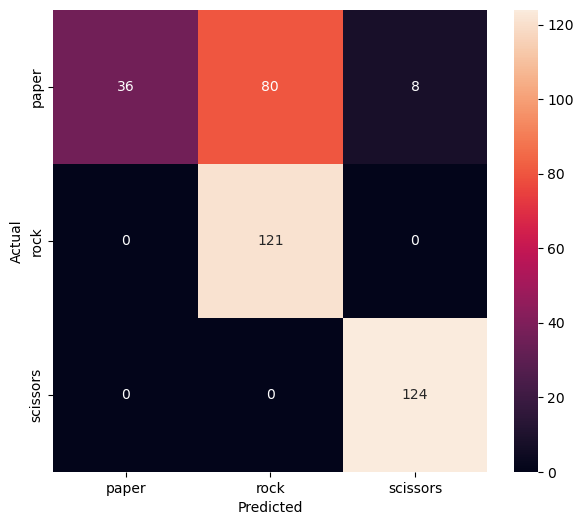

In [31]:
plt.figure(figsize=(7,6))


sns.heatmap(

    confusion_matrix(
        y_test,
        pred
    ),

    annot=True,

    fmt="d",

    xticklabels=encoder.classes_,

    yticklabels=encoder.classes_

)


plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

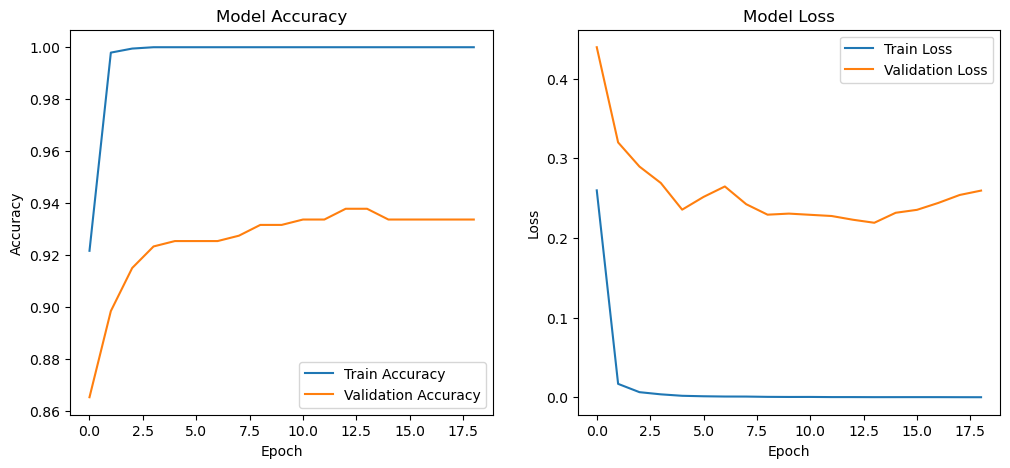

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

#Loss
plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [34]:
MODEL_PATH = r"C:\Users\hp\Documents\innomatics\DL\Rock_Paper_Scissor\model\final_model.keras"

final_model.save(MODEL_PATH)